# This Notebook contains codes to run DS & ML models on local windows machine.

After labelling this sample, I will load them in and analyse

### Traditional DS Models - Classification

In this section, I considered logistic regression, random forest and XGBoost for classifying the articles. I also did hyperparameter tuning using 5-fold cross validation. 

In [39]:
import pandas as pd
import numpy as np
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, make_scorer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# ----------- Custom Transformers -----------

class TextSelector(BaseEstimator, TransformerMixin):
    def __init__(self, key):
        self.key = key

    def fit(self, X, y=None): return self

    def transform(self, X):
        return X[self.key].fillna("")


class NormalizedKeywordCountExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, keywords, column):
        self.keywords = keywords
        self.column = column

    def fit(self, X, y=None): return self

    def transform(self, X):
        col = X[self.column].fillna("")
        pattern = '|'.join(re.escape(kw) for kw in self.keywords)

        def keyword_density(text):
            words = text.split()
            word_count = len(words) if len(words) > 0 else 1
            keyword_count = len(re.findall(pattern, text, flags=re.IGNORECASE))
            return keyword_count / word_count

        densities = col.apply(keyword_density)
        return pd.DataFrame({f"{self.column}_keyword_density": densities})


# ----------- Main Evaluator Class -----------

class NewsClassifierEvaluator:
    def __init__(self, df, label_col, tfidf_cols, keyword_cols, keywords=None, test_size=0.2, random_state=42):
        self.df = df.copy()
        self.label_col = label_col
        self.tfidf_cols = tfidf_cols
        self.keyword_cols = keyword_cols
        self.keywords = keywords or ["fraud", "money laundering", "corruption", "sanction", "embezzlement"]
        self.test_size = test_size
        self.random_state = random_state

        self.models = {
            'LogisticRegression': LogisticRegression(max_iter=1000),
            'RandomForest': RandomForestClassifier(),
            'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
        }

        self.param_grids = {
            'LogisticRegression': {
                'clf__C': [0.01, 0.1, 1, 10]
            },
            'RandomForest': {
                'clf__n_estimators': [100, 200],
                'clf__max_depth': [None, 10, 20]
            },
            'XGBoost': {
                'clf__n_estimators': [100, 200],
                'clf__max_depth': [3, 5, 7],
                'clf__learning_rate': [0.05, 0.1]
            }
        }

        self.X_train, self.X_test, self.y_train, self.y_test = self._train_test_split()

    def _train_test_split(self):
        return train_test_split(
            self.df,
            self.df[self.label_col],
            test_size=self.test_size,
            stratify=self.df[self.label_col],
            random_state=self.random_state
        )

    def _evaluate_model(self, y_true, y_pred, y_proba):
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1 Score': f1_score(y_true, y_pred),
            'ROC AUC': roc_auc_score(y_true, y_proba)
        }

    def _build_pipeline(self, model):
        feature_extractors = []

        for col in self.tfidf_cols:
            feature_extractors.append((
                f"{col}_tfidf",
                Pipeline([
                    ('select', TextSelector(col)),
                    ('tfidf', TfidfVectorizer(max_features=3000, stop_words='english'))
                ])
            ))

        for col in self.keyword_cols:
            feature_extractors.append((
                f"{col}_keyword_density",
                NormalizedKeywordCountExtractor(self.keywords, column=col)
            ))

        return Pipeline([
            ('features', FeatureUnion(feature_extractors)),
            ('clf', model)
        ])

    def cross_validate_model(self, model_name, k=5, tune=False):
        '''
        Cross validates the model
        '''
        model = self.models[model_name]
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=self.random_state)
        metrics_list = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_train, self.y_train), 1):
            train_df = self.X_train.iloc[train_idx]
            val_df = self.X_train.iloc[val_idx]
            y_train_fold = self.y_train.iloc[train_idx]
            y_val_fold = self.y_train.iloc[val_idx]

            pipeline = self._build_pipeline(model)

            if tune:
                param_grid = self.param_grids[model_name]
                grid = GridSearchCV(pipeline, param_grid, scoring='f1', cv=3, n_jobs=-1)
                grid.fit(train_df, y_train_fold)
                best_pipeline = grid.best_estimator_
            else:
                pipeline.fit(train_df, y_train_fold)
                best_pipeline = pipeline

            y_pred = best_pipeline.predict(val_df)
            y_proba = best_pipeline.predict_proba(val_df)[:, 1]

            metrics = self._evaluate_model(y_val_fold, y_pred, y_proba)
            metrics['Fold'] = fold
            metrics_list.append(metrics)

        return pd.DataFrame(metrics_list)

    def evaluate_on_holdout(self, model_name, tune=False):
        model = self.models[model_name]
        pipeline = self._build_pipeline(model)

        if tune:
            param_grid = self.param_grids[model_name]
            grid = GridSearchCV(pipeline, param_grid, scoring='f1', cv=3, n_jobs=-1)
            grid.fit(self.X_train, self.y_train)
            pipeline = grid.best_estimator_
        else:
            pipeline.fit(self.X_train, self.y_train)

        y_pred = pipeline.predict(self.X_test)
        y_proba = pipeline.predict_proba(self.X_test)[:, 1]

        return self._evaluate_model(self.y_test, y_pred, y_proba)


# ----------- Example Usage -----------

if __name__ == '__main__':
    df = pd.read_excel("./sample_labelled/sample_labelled.xlsx", engine="openpyxl")

    evaluator = NewsClassifierEvaluator(
        df=df,
        label_col='adverse_news_financial_crime_scandal_sanctions',
        tfidf_cols=['title', 'description', 'clean_full_text'],
        keyword_cols=['title', 'description','clean_full_text'],
        keywords=[
            "fraud", "money laundering", "corruption", "bribery",
            "sanction", 'ponzi', 'pyramid scheme',
            'insider trading', 'terrorist financing', 'tax-evasion'
        ]
    )

    evaluation_df = pd.DataFrame()

    for model_name in evaluator.models:
        print(f"\nTuned cross-validation results for {model_name}:")
        cv_results = evaluator.cross_validate_model(model_name, tune=True)
        cv_results['model'] = model_name
        cv_results['type_of_eval'] = 'CV'
        evaluation_df = pd.concat((evaluation_df, cv_results), ignore_index=True)
        print(cv_results.drop(columns='Fold').mean(numeric_only=True))

        print(f"\nTuned hold-out evaluation for {model_name}:")
        holdout_results = evaluator.evaluate_on_holdout(model_name, tune=True)
        holdout_results['model'] = model_name
        holdout_results['type_of_eval'] = 'test/hold-out'
        evaluation_df = pd.concat((evaluation_df, pd.DataFrame([holdout_results])), ignore_index=True)
        print(holdout_results)


    evaluation_df.to_excel('evaluation/evaluation_simple_classifiers.xlsx', index = False)


Tuned cross-validation results for LogisticRegression:
Accuracy     0.813750
Precision    0.811545
Recall       0.876002
F1 Score     0.842120
ROC AUC      0.894568
dtype: float64

Tuned hold-out evaluation for LogisticRegression:
{'Accuracy': 0.8316666666666667, 'Precision': 0.8278688524590164, 'Recall': 0.8885630498533724, 'F1 Score': 0.8571428571428571, 'ROC AUC': np.float64(0.9133708488547199), 'model': 'LogisticRegression', 'type_of_eval': 'test/hold-out'}

Tuned cross-validation results for RandomForest:
Accuracy     0.809583
Precision    0.775045
Recall       0.936907
F1 Score     0.848255
ROC AUC      0.909678
dtype: float64

Tuned hold-out evaluation for RandomForest:
{'Accuracy': 0.8166666666666667, 'Precision': 0.78239608801956, 'Recall': 0.9384164222873901, 'F1 Score': 0.8533333333333334, 'ROC AUC': np.float64(0.914922043954302), 'model': 'RandomForest', 'type_of_eval': 'test/hold-out'}

Tuned cross-validation results for XGBoost:
Accuracy     0.828750
Precision    0.83572

### Topic Modelling using BerTopics + MLP Classifier based on BerTopics + other features

Steps I did in the following code:
1. Do a train, validation, test split (60-20-20).
2. Use the clean_full_text column as text column to get TF-IDF, use title and description for pre-defined keyword counts (normalised, i.e. divided by total number of tokens) occurring within the title and description
3. Run BerTopics Topic Modelling then get top topics, iteratively check cosine similarity of these topics with the pre-defined keywords until we get at least 5 topics which are similar to our pre-defined keywords relating to financial crime/sanctions/scandals.
4. Use those features created in steps 2 and 3, together with the labels, using the embeddings in BerTopics model, train a MLP

I believe the text is too noisy, so it obscures signals from the data and more work is required for feature engineering

In [78]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer, util
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from typing import List

# Check for BERTopic availability
try:
    from bertopic import BERTopic
    BERTopic_AVAILABLE = True
except ImportError:
    BERTopic_AVAILABLE = False


# ----- Feature Extractor Classes -----

class TextSelector(BaseEstimator, TransformerMixin):
    """
    Transformer to select a specific text column from a DataFrame.
    """
    def __init__(self, column):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.column].fillna("")


class KeywordDensityExtractor(BaseEstimator, TransformerMixin):
    """
    Extracts the density of specified keywords in a given text column.
    """
    def __init__(self, keywords, column):
        self.keywords = keywords
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return pd.DataFrame([
            [text.lower().count(kw.lower()) / (len(text.split()) + 1e-6) for kw in self.keywords]
            for text in X[self.column].fillna("")
        ])


class TopicFeatureAdder(BaseEstimator, TransformerMixin):
    """
    Adds binary topic relevance features based on BERTopic model results.
    """
    def __init__(self, topic_model: BERTopic, text_column: str, relevant_topic_ids: List[int]):
        self.topic_model = topic_model
        self.text_column = text_column
        self.relevant_topic_ids = relevant_topic_ids

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        texts = X[self.text_column].fillna("").tolist()
        topics, _ = self.topic_model.transform(texts)
        return pd.DataFrame([[int(t in self.relevant_topic_ids)] for t in topics], index=X.index)


# ----- PyTorch Dataset -----

class FeatureDataset(Dataset):
    """
    Custom Dataset class for loading feature and label tensors.
    """
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# ----- Neural Network Classifier -----

class MLPClassifier(nn.Module):
    """
    A simple multi-layer perceptron classifier for binary classification.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.model(x)


# ----- Main Classifier Pipeline -----

class BerTopicsEnhancedClassifier:
    """
    An end-to-end classification pipeline that integrates TF-IDF, keyword density,
    transformer embeddings, and optionally BERTopic features.
    """
    def __init__(self, df: pd.DataFrame, label_col: str, text_col: str = 'clean_full_text',
                 keyword_cols: List[str] = None, keywords: List[str] = None,
                 use_tfidf: bool = True, use_bertopic: bool = True):
        self.df = df.copy()
        self.label_col = label_col
        self.text_col = text_col
        self.keyword_cols = keyword_cols or ['title', 'description']
        self.keywords = keywords or [
            "fraud", "money laundering", "corruption", "bribery",
            "sanction", "ponzi", "pyramid scheme",
            "insider trading", "terrorist financing", "tax-evasion"
        ]
        self.use_tfidf = use_tfidf
        self.use_bertopic = use_bertopic and BERTopic_AVAILABLE

        # Combine multiple text fields for topic modeling
        self.df['topic_text'] = self.df[self.keyword_cols].fillna("").agg(" ".join, axis=1)
        self.embedding_model = SentenceTransformer("all-MiniLM-L12-v2")
        self._split_data()
        if self.use_bertopic:
            self._initialize_topic_model_with_relevance_filter()

    def _split_data(self):
        """
        Splits the dataset into training, validation, and test sets.
        """
        train_val_df, self.test_df = train_test_split(
            self.df, test_size=0.2, stratify=self.df[self.label_col], random_state=42)
        self.train_df, self.val_df = train_test_split(
            train_val_df, test_size=0.25, stratify=train_val_df[self.label_col], random_state=42)

    def _initialize_topic_model_with_relevance_filter(self):
        """
        Initializes BERTopic and filters topics based on semantic similarity
        to the defined keywords.
        """
        current_train_texts = self.train_df['topic_text'].tolist()
        min_relevant = 5
        iteration = 0
        relevant_topic_ids = []

        while len(relevant_topic_ids) < min_relevant and iteration < 5:
            self.topic_model = BERTopic(embedding_model=self.embedding_model)
            topics, _ = self.topic_model.fit_transform(current_train_texts)
            topic_info = self.topic_model.get_topic_info()
            topic_ids = topic_info['Topic'].tolist()
            topic_keywords = [" ".join([w for w, _ in self.topic_model.get_topic(t)[:5]])
                              for t in topic_ids if t != -1]

            topic_embeddings = self.embedding_model.encode(topic_keywords, convert_to_tensor=True)
            keyword_embeddings = self.embedding_model.encode(self.keywords, convert_to_tensor=True)
            similarities = util.cos_sim(topic_embeddings, keyword_embeddings)

            relevant_topic_ids = [topic_ids[i] for i in range(len(topic_ids))
                                  if i < similarities.shape[0] and similarities[i].max().item() > 0.4 and topic_ids[i] != -1]
            iteration += 1

        self.relevant_topic_ids = relevant_topic_ids

    def preprocess_features(self, df, fit=True):
        """
        Extracts and combines all features (TF-IDF, keyword density, topic relevance, embeddings).
        Uses only training data for fitting components to avoid data leakage.
        """
        if fit:
            feature_extractors = []
            if self.use_tfidf:
                feature_extractors.append((
                    "tfidf", Pipeline([
                        ('select', TextSelector(self.text_col)),
                        ('tfidf', TfidfVectorizer(max_features=3000, stop_words='english'))
                    ])
                ))

            for col in self.keyword_cols:
                feature_extractors.append((
                    f"{col}_keywords",
                    KeywordDensityExtractor(self.keywords, column=col)
                ))

            if self.use_bertopic:
                feature_extractors.append((
                    "topic", TopicFeatureAdder(self.topic_model, text_column='topic_text',
                                               relevant_topic_ids=self.relevant_topic_ids)
                ))

            self.feature_pipeline = FeatureUnion(feature_extractors)
            base_features = self.feature_pipeline.fit_transform(df)

            self.scaler = StandardScaler()
        else:
            base_features = self.feature_pipeline.transform(df)

        if hasattr(base_features, "toarray"):
            base_features = base_features.toarray()
        if base_features.ndim == 1:
            base_features = base_features.reshape(-1, 1)

        embeddings = self.embedding_model.encode(df[self.text_col].fillna("").tolist(), show_progress_bar=True)
        embeddings = np.array(embeddings)
        if embeddings.ndim == 1:
            embeddings = embeddings.reshape(-1, 1)

        combined = np.hstack([base_features, embeddings])

        if fit:
            combined_scaled = self.scaler.fit_transform(combined)
        else:
            combined_scaled = self.scaler.transform(combined)

        return combined_scaled


    def train(self, epochs=10, batch_size=32, lr=1e-3, patience=5):
        """
        Trains the MLP classifier using the training and validation sets with early stopping.
        """
        X_train = self.preprocess_features(self.train_df, fit=True)
        y_train = self.train_df[self.label_col].values
        X_val = self.preprocess_features(self.val_df, fit=False)
        y_val = self.val_df[self.label_col].values

        train_loader = DataLoader(FeatureDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(FeatureDataset(X_val, y_val), batch_size=batch_size)

        model = MLPClassifier(X_train.shape[1])
        self.model = model
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.criterion = nn.CrossEntropyLoss()

        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(epochs):
            model.train()
            running_train_loss = 0.0
            for X_batch, y_batch in train_loader:
                self.optimizer.zero_grad()
                out = model(X_batch)
                loss = self.criterion(out, y_batch)
                loss.backward()
                self.optimizer.step()
                running_train_loss += loss.item() * X_batch.size(0)

            epoch_train_loss = running_train_loss / len(train_loader.dataset)

            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for X_val_batch, y_val_batch in val_loader:
                    outputs = model(X_val_batch)
                    val_loss = self.criterion(outputs, y_val_batch)
                    running_val_loss += val_loss.item() * X_val_batch.size(0)
            epoch_val_loss = running_val_loss / len(val_loader.dataset)

            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

            # Early Stopping logic
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                patience_counter = 0
                best_model_state = model.state_dict()
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    break

        # Restore best model
        model.load_state_dict(best_model_state)


    def evaluate(self):
        """
        Evaluates the trained model on the test set and prints the classification report.
        """
        from sklearn.metrics import classification_report

        X_test = self.preprocess_features(self.test_df, fit=False)
        y_test = self.test_df[self.label_col].values
        test_dataset = FeatureDataset(X_test, y_test)
        loader = DataLoader(test_dataset, batch_size=32)

        self.model.eval()
        preds = []
        with torch.no_grad():
            for X_batch, _ in loader:
                outputs = self.model(X_batch)
                pred_labels = torch.argmax(outputs, dim=1)
                preds.extend(pred_labels.numpy())

        print(classification_report(y_test, preds))
        return classification_report(y_test, preds, output_dict=True)


In [79]:
df = pd.read_excel("./sample_labelled/sample_labelled.xlsx", engine="openpyxl")

# Keywords to track
keywords = ["fraud", "money laundering", "corruption", "bribery",
            "sanction", 'ponzi', 'pyramid scheme',
            'insider trading', 'terrorist financing', 'tax-evasion']

# Columns you want to compute keyword density on
keyword_cols = ['title', 'description']

# Initialize the classifier
clf = BerTopicsEnhancedClassifier(
    df=df,
    label_col='adverse_news_financial_crime_scandal_sanctions',
    text_col='clean_full_text',
    keyword_cols=keyword_cols,
    keywords=keywords,
    use_tfidf=True
)

# Train the model
clf.train(epochs=100, batch_size=32, lr=8e-6)

# Evaluate it
bertopic_mlp_eval_df = pd.DataFrame(clf.evaluate()).transpose()
bertopic_mlp_eval_df.to_excel('evaluation/evaluation_MLPClassifier_BERTOPICS.xlsx', index = False)

Batches: 100%|█████████████████████████████████████████████████████████████████████████| 19/19 [00:01<00:00, 10.93it/s]


Epoch 1/100 - Train Loss: 0.7023 - Val Loss: 0.6767
Epoch 2/100 - Train Loss: 0.6633 - Val Loss: 0.6507
Epoch 3/100 - Train Loss: 0.6373 - Val Loss: 0.6272
Epoch 4/100 - Train Loss: 0.6100 - Val Loss: 0.6092
Epoch 5/100 - Train Loss: 0.5961 - Val Loss: 0.5973
Epoch 6/100 - Train Loss: 0.5710 - Val Loss: 0.5827
Epoch 7/100 - Train Loss: 0.5568 - Val Loss: 0.5642
Epoch 8/100 - Train Loss: 0.5489 - Val Loss: 0.5585
Epoch 9/100 - Train Loss: 0.5314 - Val Loss: 0.5456
Epoch 10/100 - Train Loss: 0.5168 - Val Loss: 0.5337
Epoch 11/100 - Train Loss: 0.5084 - Val Loss: 0.5315
Epoch 12/100 - Train Loss: 0.4902 - Val Loss: 0.5211
Epoch 13/100 - Train Loss: 0.4819 - Val Loss: 0.5149
Epoch 14/100 - Train Loss: 0.4665 - Val Loss: 0.5097
Epoch 15/100 - Train Loss: 0.4644 - Val Loss: 0.5025
Epoch 16/100 - Train Loss: 0.4511 - Val Loss: 0.4931
Epoch 17/100 - Train Loss: 0.4503 - Val Loss: 0.4878
Epoch 18/100 - Train Loss: 0.4306 - Val Loss: 0.4855
Epoch 19/100 - Train Loss: 0.4296 - Val Loss: 0.4799
Ep

Batches: 100%|█████████████████████████████████████████████████████████████████████████| 19/19 [00:01<00:00, 11.68it/s]


              precision    recall  f1-score   support

           0       0.82      0.80      0.81       259
           1       0.85      0.87      0.86       341

    accuracy                           0.83       600
   macro avg       0.83      0.83      0.83       600
weighted avg       0.83      0.83      0.83       600



### Using Topic Modelling + Cosine Similarity to Assign pre-defined categories

In [56]:
from sentence_transformers import SentenceTransformer, util
import numpy as np

class MultiLabelCategoryAssigner:
    def __init__(self, categories, model_name="all-MiniLM-L12-v2", threshold=0.4):
        """
        Initialize the assigner with a list of pre-defined categories.
        Parameters:
        - categories (List[str]): The category labels, e.g., ["fraud", "money laundering", ...]
        - model_name (str): Name of the SentenceTransformer model.
        - threshold (float): Similarity threshold above which a category is assigned.
        """
        self.categories = categories
        self.threshold = threshold
        self.model = SentenceTransformer(model_name)
        # Pre-compute category embeddings once.
        self.category_embeddings = self.model.encode(categories, convert_to_tensor=True)

    def assign_categories(self, text):
        """
        Given a text, compute its embedding and determine which of the pre-defined categories
        it matches by exceeding the similarity threshold.
        Returns:
        - List[str]: List of categories assigned to the text.
        """
        # Compute document embedding
        doc_embedding = self.model.encode(text, convert_to_tensor=True)
        # Compute cosine similarity between doc and each category
        similarities = util.cos_sim(doc_embedding, self.category_embeddings).cpu().numpy().flatten()
        # Select all categories where similarity exceeds the threshold
        assigned = [cat for cat, sim in zip(self.categories, similarities) if sim >= self.threshold]
        return assigned

categories = ["fraud", "money laundering", "corruption", "bribery",
              "sanction", "ponzi", "pyramid scheme", "insider trading", "terrorist financing", "tax-evasion"]

assigner = MultiLabelCategoryAssigner(categories, threshold=0.4)

# Assign categories of financial crime
df['related_categories'] = df['clean_full_text'].apply(lambda x:assigner.assign_categories(x))
df.to_excel('./categories_pred/topic_modelling_similarity_assigned.xlsx', index = False)

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm


class MultiLabelClusterAssigner:
    def __init__(self, documents, categories, model_name="all-MiniLM-L12-v2", 
                 n_clusters=10, threshold=0.4):
        """
        Initialize the assigner by clustering document embeddings and then mapping
        each cluster to one or more of the pre-defined categories.
        """
        self.categories = categories
        self.threshold = threshold
        self.model = SentenceTransformer(model_name)
        
        # Compute document embeddings
        print("Computing embeddings for documents...")
        self.doc_embeddings = self.model.encode(documents, show_progress_bar=True)

        # Store documents in case you want to re-cluster later
        self.documents = documents

        # Perform clustering
        self.fit_kmeans(n_clusters)

        # Compute category embeddings
        print("Computing embeddings for categories...")
        self.category_embeddings = self.model.encode(categories, convert_to_tensor=False)

        # Map each cluster to categories
        self.map_clusters_to_categories()

    def fit_kmeans(self, n_clusters):
        """
        Fit KMeans and store cluster centers and labels.
        """
        print(f"Clustering into {n_clusters} clusters...")
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        self.cluster_labels = self.kmeans.fit_predict(self.doc_embeddings)
        self.cluster_centers = self.kmeans.cluster_centers_

    def map_clusters_to_categories(self):
        """
        Map each cluster center to related categories using cosine similarity.
        """
        self.cluster_to_categories = {}
        for cluster in range(len(self.cluster_centers)):
            center = self.cluster_centers[cluster].reshape(1, -1)
            sims = cosine_similarity(center, self.category_embeddings)[0]
            assigned = [cat for cat, sim in zip(self.categories, sims) if sim >= self.threshold]
            self.cluster_to_categories[cluster] = assigned

        print("Cluster-to-category mapping created:")
        for cluster, cats in self.cluster_to_categories.items():
            print(f"Cluster {cluster}: {cats}")

    def assign_document_categories(self, document):
        """
        Assigns categories to a single document based on nearest cluster.
        """
        doc_embedding = self.model.encode(document)
        distances = np.linalg.norm(self.cluster_centers - doc_embedding, axis=1)
        cluster = np.argmin(distances)
        return self.cluster_to_categories.get(cluster, [])

    def assign_documents(self, documents):
        """
        Assign categories to a list of documents.
        """
        return [self.assign_document_categories(doc) for doc in documents]

    def plot_elbow(self, k_range=range(2, 20)):
        """
        Plot elbow method graph to determine optimal k.
        """
        inertias = []
        print("Computing inertia for different k values...")
        for k in tqdm(k_range):
            km = KMeans(n_clusters=k, random_state=42)
            km.fit(self.doc_embeddings)
            inertias.append(km.inertia_)

        plt.figure(figsize=(8, 5))
        plt.plot(list(k_range), inertias, marker='o')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("Inertia (within-cluster sum of squares)")
        plt.title("Elbow Method for Optimal k")
        plt.grid(True)
        plt.show()

    @staticmethod
    def compute_inertias(embeddings, k_range=range(2, 20)):
        """
        Static method to compute inertias given precomputed embeddings.
        """
        inertias = []
        for k in k_range:
            km = KMeans(n_clusters=k, random_state=42)
            km.fit(embeddings)
            inertias.append(km.inertia_)
        return inertias


Computing embeddings for documents...


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 94/94 [00:34<00:00,  2.73it/s]


Clustering into 8 clusters...
Computing embeddings for categories...
Cluster-to-category mapping created:
Cluster 0: ['fraud', 'ponzi', 'insider trading']
Cluster 1: ['fraud', 'money laundering', 'corruption', 'bribery', 'ponzi', 'insider trading', 'terrorist financing', 'tax-evasion']
Cluster 2: ['fraud']
Cluster 3: []
Cluster 4: []
Cluster 5: []
Cluster 6: ['corruption', 'bribery', 'sanction', 'terrorist financing']
Cluster 7: []
Computing inertia for different k values...


100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:02<00:00,  5.24it/s]


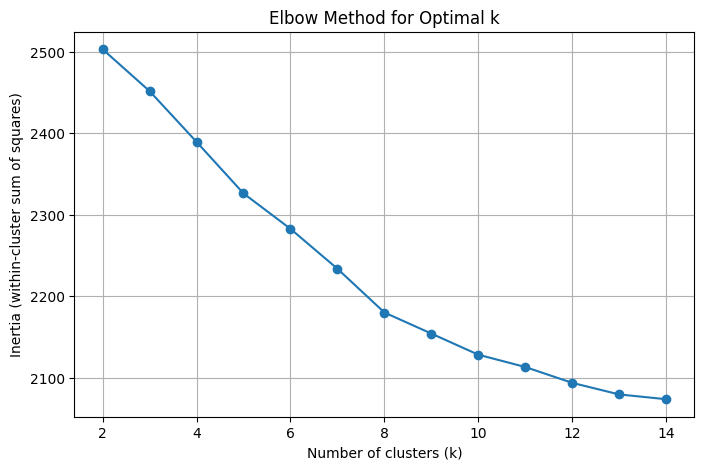

In [83]:
# Pre-defined adverse news categories
categories = [
    "fraud", "money laundering", "corruption", "bribery",
    "sanction", "ponzi", "pyramid scheme", "insider trading", 
    "terrorist financing", "tax-evasion"
]

# List of documents from your DataFrame
documents = df["clean_full_text"].fillna("").tolist()

# Initialize the cluster assigner (pick any n_clusters to start)
cluster_assigner = MultiLabelClusterAssigner(documents, categories, n_clusters=8)

# Plot elbow to help decide optimal k
cluster_assigner.plot_elbow(k_range=range(2, 15))

In [86]:
# Assign categories
df['related_categories_cluster_method'] = cluster_assigner.assign_documents(df['clean_full_text'])

# Save output
df.to_excel('./categories_pred/multi_label_cluster_assigned.xlsx', index=False)